# Custom DGP Design

This notebook uses the configurable HawkesNest DGP path directly. It does not import old scripts or use prebaked suites.

In [1]:
from hawkesnest.config import SimulatorConfig
from hawkesnest.viz import plot_events_2d, plot_events_3d, plot_intensity_snapshots

def simulate_config(config, *, n_events=60, seed=0, tau_max=5.0):
    cfg = SimulatorConfig.model_validate(config)
    sim = cfg.build()
    events, parents = sim.simulate(n=n_events, seed=seed, tau_max=tau_max, debug=False)
    return cfg, events, parents

base_domain = {"type": "rectangle", "x_min": 0.0, "x_max": 1.0, "y_min": 0.0, "y_max": 1.0}

## 1. Homogeneous baseline

A simple marked-free process with a constant background and weak self-excitation.

In [2]:
constant_config = {
    "domain": base_domain,
    "backgrounds": [{"type": "constant", "rate": 2.0}],
    "kernels": [{"type": "separable", "temporal_decay": 0.5, "spatial_sigma": 0.12}],
    "adjacency": [[0.05]],
    "lambda_max": 8.0,
}

constant_cfg, constant_events, _ = simulate_config(constant_config, n_events=50, seed=1)
constant_events.head()

          t         x         y  m  is_triggered
0  0.963442  0.969925  0.516069  1         False
1  1.426133  0.528589  0.459336  1          True
2  1.948888  0.802364  0.191324  1          True
3  2.193710  0.422717  0.589502  1          True
4  2.294998  0.245552  0.768517  1          True

## 2. Painted spatial clusters

A spatially structured background paints likely event regions before thinning samples the event stream.

In [3]:
cluster_config = {
    "domain": base_domain,
    "backgrounds": [{
        "type": "function",
        "name": "cluster_mix",
        "centers": [[0.25, 0.25], [0.75, 0.65]],
        "sigma": 0.12,
        "a0": 0.2,
        "amp": 1.5,
    }],
    "kernels": [{"type": "separable", "temporal_decay": 0.4, "spatial_sigma": 0.12}],
    "adjacency": [[0.20]],
    "lambda_max": 25.0,
}

cluster_cfg, cluster_events, _ = simulate_config(cluster_config, n_events=60, seed=2)
cluster_events.head()

          t         x         y  m  is_triggered
0  2.011941  0.829319  0.962819  1         False
1  2.267782  0.733224  0.265226  1          True
2  4.106892  0.619896  0.688923  1          True
3  4.249600  0.329953  0.745617  1          True
4  4.764660  0.798155  0.997561  1          True

## 3. Marked process with a moving hotspot

Two marks can have different backgrounds while sharing a broadcast kernel. The adjacency matrix controls cross-mark triggering.

In [4]:
marked_config = {
    "domain": base_domain,
    "backgrounds": [
        {"type": "constant", "rate": 1.2},
        {
            "type": "function",
            "name": "moving_hotspots",
            "start": [0.45, 0.45],
            "v": [0.002, 0.001],
            "sigma": 0.08,
            "a0": 0.4,
            "amp": 0.8,
        },
    ],
    "kernels": [{"type": "separable", "temporal_decay": 0.35, "spatial_sigma": 0.10}],
    "adjacency": [[0.10, 0.05], [0.25, 0.10]],
    "lambda_max": 35.0,
}

marked_cfg, marked_events, _ = simulate_config(marked_config, n_events=70, seed=3)
marked_events["m"].value_counts().sort_index()

m
1    44
2    26
Name: count, dtype: int64

## Event clouds

Compare the generated events spatially, then inspect the marked process in 3D.

notebooks/04_custom_dgp_design.ipynb:9:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/04_custom_dgp_design.ipynb:9:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


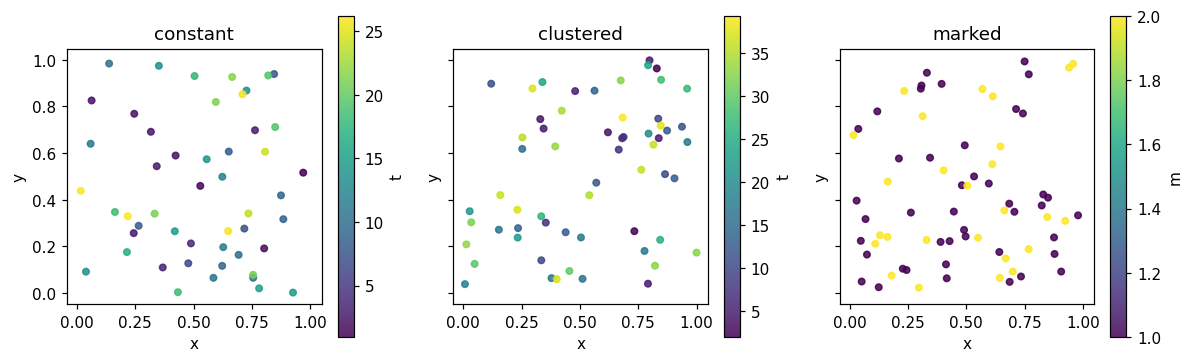

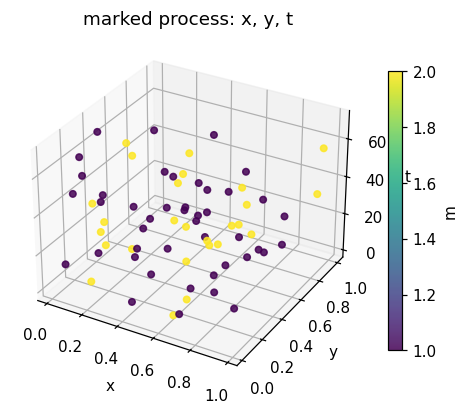

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharex=True, sharey=True)
plot_events_2d(constant_events, ax=axes[0], color_by="t", title="constant")
plot_events_2d(cluster_events, ax=axes[1], color_by="t", title="clustered")
plot_events_2d(marked_events, ax=axes[2], color_by="m", title="marked")
plt.tight_layout()
plt.show()

fig, ax = plot_events_3d(marked_events, color_by="m", title="marked process: x, y, t")
plt.show()

## Intensity snapshots

The same configs can be inspected as intensity surfaces before event sampling.

notebooks/04_custom_dgp_design.ipynb:11:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/04_custom_dgp_design.ipynb:11:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


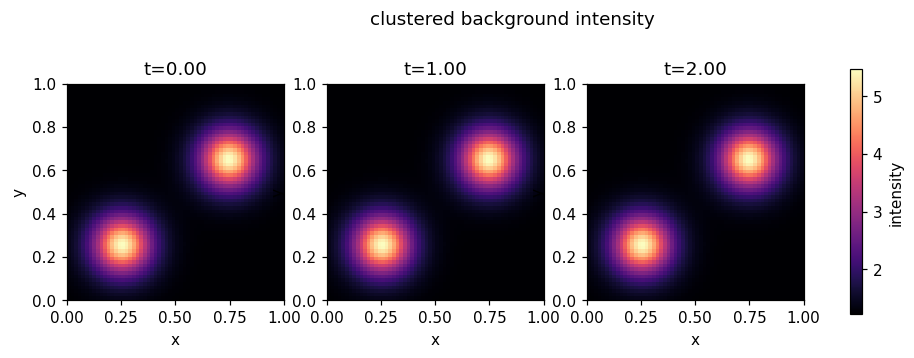

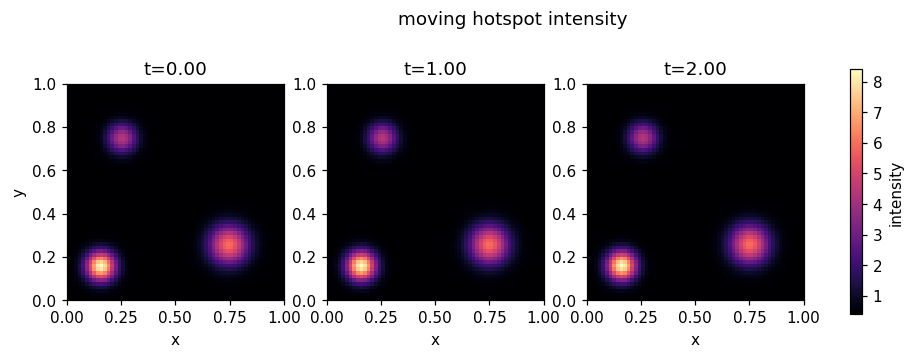

In [6]:
cluster_background = cluster_cfg.backgrounds[0].build()
fig, axes = plot_intensity_snapshots(
    lambda s, t: cluster_background(s, t),
    times=[0.0, 1.0, 2.0],
    title="clustered background intensity",
)
plt.show()

moving_background = marked_cfg.backgrounds[1].build(idx=1)
fig, axes = plot_intensity_snapshots(
    lambda s, t: moving_background(s, t),
    times=[0.0, 1.0, 2.0],
    title="moving hotspot intensity",
)
plt.show()